# STING (STatistical INformation Grid) Clustering

- STING: grid-based clustering algorithm — divides the data space into rectangular cells and finds dense regions
- Bottom-up approach: identifies dense cells at a fine resolution, then merges adjacent dense cells into clusters
- No sklearn implementation — built from scratch using NumPy
- Dataset: Mall_Customers.csv (same as KMeans and Hierarchical — for direct comparison)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("Mall_Customers.csv")

X = df[["Annual Income (k$)", "Spending Score (1-100)"]].values

print("Shape:", X.shape)
print(df.head())


Shape: (200, 2)
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [4]:
sc = StandardScaler()
X_scaled = sc.fit_transform(X)

In [5]:
# STING Implementation from scratch

class STING:
    def __init__(self, grid_size=10, density_threshold=0.05):
        # grid_size: number of cells per dimension (grid_size x grid_size total cells)
        # density_threshold: minimum fraction of total points a cell must contain to be "dense"
        self.grid_size = grid_size
        self.density_threshold = density_threshold

    def fit_predict(self, X):
        n = len(X)

        # Step 1: define grid boundaries across each dimension
        x_bins = np.linspace(X[:, 0].min(), X[:, 0].max(), self.grid_size + 1)
        y_bins = np.linspace(X[:, 1].min(), X[:, 1].max(), self.grid_size + 1)

        # Step 2: count points in each cell
        grid = np.zeros((self.grid_size, self.grid_size))
        for point in X:
            xi = min(np.searchsorted(x_bins, point[0]) - 1, self.grid_size - 1)
            yi = min(np.searchsorted(y_bins, point[1]) - 1, self.grid_size - 1)
            xi, yi = max(0, xi), max(0, yi)
            grid[xi, yi] += 1

        # Step 3: compute density (fraction of total points per cell)
        density = grid / n

        # Step 4: mark cells as dense if they meet the threshold
        dense = density >= self.density_threshold

        # Step 5: connected component labeling via BFS
        # adjacent dense cells are merged into the same cluster
        labels_grid = np.full((self.grid_size, self.grid_size), -1)
        cluster_id = 0

        for i in range(self.grid_size):
            for j in range(self.grid_size):
                if dense[i, j] and labels_grid[i, j] == -1:
                    queue = [(i, j)]
                    labels_grid[i, j] = cluster_id
                    while queue:
                        ci, cj = queue.pop(0)
                        for di, dj in [(-1,0),(1,0),(0,-1),(0,1)]:
                            ni, nj = ci + di, cj + dj
                            if 0 <= ni < self.grid_size and 0 <= nj < self.grid_size:
                                if dense[ni, nj] and labels_grid[ni, nj] == -1:
                                    labels_grid[ni, nj] = cluster_id
                                    queue.append((ni, nj))
                    cluster_id += 1

        # Step 6: assign each point the label of its cell
        point_labels = np.full(n, -1)
        for i, point in enumerate(X):
            xi = min(np.searchsorted(x_bins, point[0]) - 1, self.grid_size - 1)
            yi = min(np.searchsorted(y_bins, point[1]) - 1, self.grid_size - 1)
            xi, yi = max(0, xi), max(0, yi)
            point_labels[i] = labels_grid[xi, yi]

        self.grid_ = grid
        self.density_ = density
        self.dense_ = dense
        self.labels_grid_ = labels_grid
        self.x_bins_ = x_bins
        self.y_bins_ = y_bins

        return point_labels


In [7]:
model = STING(grid_size=10, density_threshold=0.04)
labels = model.fit_predict(X_scaled)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print("Clusters found:", n_clusters)
print("Noise points  :", list(labels).count(-1))

Clusters found: 2
Noise points  : 130


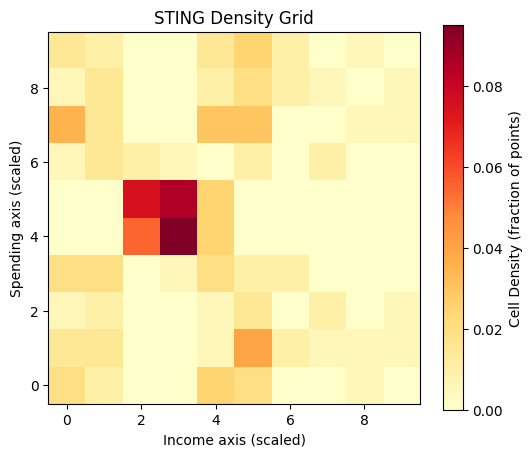

In [8]:
# Visualize the density grid
plt.figure(figsize=(6, 5))
plt.imshow(model.density_.T, origin="lower", cmap="YlOrRd")
plt.colorbar(label="Cell Density (fraction of points)")
plt.title("STING Density Grid")
plt.xlabel("Income axis (scaled)")
plt.ylabel("Spending axis (scaled)")
plt.show()
# Each cell's color shows what fraction of all customers fall in it
# Bright red cells = dense regions = clusters

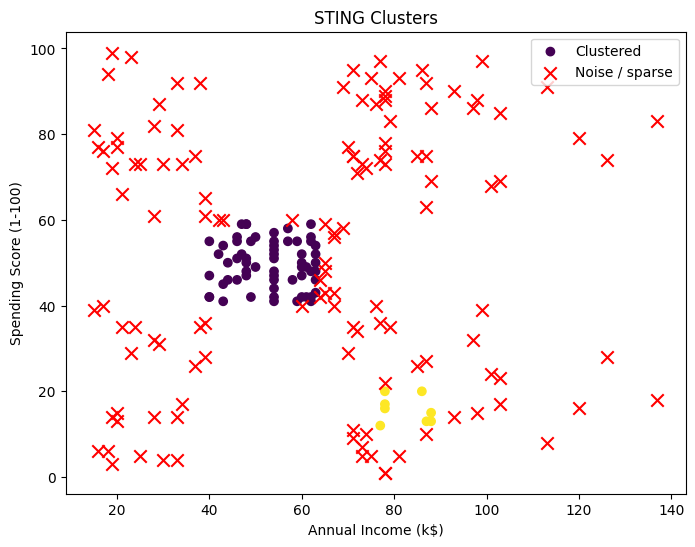

In [9]:
# Visualize clusters vs noise on original feature scale
plt.figure(figsize=(8, 6))
mask_noise = labels == -1
plt.scatter(X[~mask_noise, 0], X[~mask_noise, 1],
            c=labels[~mask_noise], cmap="viridis", label="Clustered")
plt.scatter(X[mask_noise, 0], X[mask_noise, 1],
            c="red", marker="x", s=80, label="Noise / sparse")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("STING Clusters")
plt.legend()
plt.show()

In [10]:
df["Cluster"] = labels
print(df[["Annual Income (k$)", "Spending Score (1-100)", "Cluster"]].head(10))
print("\nCluster distribution:\n", df["Cluster"].value_counts())

   Annual Income (k$)  Spending Score (1-100)  Cluster
0                  15                      39       -1
1                  15                      81       -1
2                  16                       6       -1
3                  16                      77       -1
4                  17                      40       -1
5                  17                      76       -1
6                  18                       6       -1
7                  18                      94       -1
8                  19                       3       -1
9                  19                      72       -1

Cluster distribution:
 Cluster
-1    130
 0     62
 1      8
Name: count, dtype: int64


## Conclusion
- STING divided the 2D feature space into a 10×10 grid and counted customers per cell
- Cells with density ≥ threshold were marked as dense; adjacent dense cells were merged into clusters via BFS
- Points in sparse cells (below the density threshold) were labeled as noise (-1), not forced into clusters
- Unlike K-Means (which needs K upfront) and Hierarchical (which merges points), STING works at the cell level — much faster on large datasets since it summarizes data into grid statistics first
- Key limitation: grid resolution (grid_size) and density_threshold both need tuning — too coarse a grid merges distinct clusters; too fine a grid breaks real clusters apart

Save as STING.ipynb
Upload to 03_Machine_Learning/06_Unsupervised_Learning/
